In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Cargo el DataSet del Titanic

In [2]:
df = sns.load_dataset('titanic',cache=True) # Carga el conjunto de datos 'titanic' utilizando la función load_dataset de la biblioteca seaborn y lo guarda en un DataFrame llamado df.
df.head() # Muestra las primeras filas del DataFrame df para obtener una vista previa de

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info() # Proporciona información sobre el DataFrame df, incluyendo el número de filas, columnas, tipos de datos y cantidad de valores no nulos en cada columna.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.describe() # Genera estadísticas descriptivas para las columnas numéricas del DataFrame df, como la media, la desviación estándar, los valores mínimos y máximos, y los percentiles.

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Búsqueda y tratamiento de datos faltantes (Nulos, NaN)

In [6]:
df['age'].value_counts(dropna=False) # Cuenta la frecuencia de cada valor único en la columna 'age' del DataFrame df y devuelve una serie con los valores únicos como índice y sus respectivas frecuencias como valores.

age
NaN      177
24.00     30
22.00     27
18.00     26
28.00     25
        ... 
36.50      1
55.50      1
0.92       1
23.50      1
74.00      1
Name: count, Length: 89, dtype: int64

In [7]:
df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.notnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True
1,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True
3,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True
887,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
888,True,True,True,False,True,True,True,True,True,True,True,False,True,True,True
889,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


In [ ]:
df.isnull().sum() # Calcula la cantidad de valores nulos en cada columna del DataFrame df y devuelve una serie con los nombres de las columnas como índice y la cantidad de valores nulos como valores.

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [10]:
df.isnull().sum().sum() # Calcula la cantidad total de valores nulos en todo el DataFrame df sumando los valores obtenidos en el paso anterior. Devuelve un número entero que representa la cantidad total de valores nulos en el DataFrame.

869

In [11]:
# Eliminar las columnas que tengan más del 50% de valores nulos
threshold = int(len(df) * 0.5) # Calcula el umbral de valores no nulos necesarios para conservar una columna, que es el 50% del número total de filas en el DataFrame df. El resultado se almacena en la variable threshold.
nuevo_df = df.dropna(thresh=threshold, axis=1) # Elimina las columnas del DataFrame df que tengan más del 50% de valores nulos y guarda el resultado en un nuevo DataFrame llamado nuevo_df. El parámetro thresh especifica el umbral de valores no nulos necesarios para conservar una columna, y axis=1 indica que se deben eliminar columnas (en lugar de filas).
nuevo_df.info() # Proporciona información sobre el nuevo DataFrame nuevo_df, incluyendo el número de filas, columnas, tipos de datos y cantidad de valores no nulos en cada columna después de eliminar las columnas con más del 50% de valores nulos.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 79.4+ KB


In [13]:
df_no_nulos = nuevo_df.dropna(axis=0, subset=['age', 'embark_town', 'embarked'], how='any') # Elimina las filas del DataFrame nuevo_df que tengan valores nulos en la columna 'age' y guarda el resultado en un nuevo DataFrame llamado df_no_nulos. El parámetro axis=0 indica que se deben eliminar filas, y subset=['age'] especifica que solo se deben considerar los valores nulos en la columna 'age' para eliminar las filas.
df_no_nulos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     712 non-null    int64   
 1   pclass       712 non-null    int64   
 2   sex          712 non-null    object  
 3   age          712 non-null    float64 
 4   sibsp        712 non-null    int64   
 5   parch        712 non-null    int64   
 6   fare         712 non-null    float64 
 7   embarked     712 non-null    object  
 8   class        712 non-null    category
 9   who          712 non-null    object  
 10  adult_male   712 non-null    bool    
 11  embark_town  712 non-null    object  
 12  alive        712 non-null    object  
 13  alone        712 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 69.0+ KB


Tratamiento de los valores faltantes del campo edad

In [14]:
media = nuevo_df['age'].mean() # Calcula la media de la columna 'age' en el DataFrame nuevo_df y almacena el resultado en la variable media.
moda = nuevo_df['age'].mode()[0] # Calcula la moda de la columna 'age' en el DataFrame nuevo_df y almacena el resultado en la variable moda. La función mode() devuelve una serie con las modas, por lo que se selecciona el primer valor con [0].
mediana = nuevo_df['age'].median() # Calcula la mediana de la columna 'age' en el DataFrame nuevo_df y almacena el resultado en la variable mediana.
nuevo_df['age'].fillna(media, inplace=True) # Rellena los valores nulos en la columna 'age' del DataFrame nuevo_df con la media calculada anteriormente. El parámetro inplace=True indica que se debe modificar el DataFrame original en lugar de crear una copia.
nuevo_df.info() # Proporciona información sobre el DataFrame nuevo_df después de rellenar

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 79.4+ KB


C:\Users\Fran\AppData\Local\Temp\ipykernel_21728\858683283.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  nuevo_df['age'].fillna(media, inplace=True) # Rellena los valores nulos en la columna 'age' del DataFrame nuevo_df con la media calculada anteriormente. El parámetro inplace=True indica que se debe modificar el DataFrame original en lugar de crear una copia.
C:\Users\Fran\AppData\Local\Temp\ipykernel_21728\858683283.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See t

In [ ]:
media = nuevo_df['age'].mean()
edades = []
for i in range(len(nuevo_df)):
    if pd.isnull(nuevo_df.loc[i, 'age']):
        if ('Mr' in nuevo_df['Name'][i]) or ('Mrs' in nuevo_df['Name'][i]):
           edades.append(33) # Si el nombre de la persona contiene 'Mr' o 'Mrs', se asigna la edad de 33 años.
        elif 'Miss' in nuevo_df['Name'][i]:
              edades.append(10) # Si el nombre de la persona contiene 'Miss', se asigna la edad de 10 años.
        else:
            edades.append(media) # Si el nombre de la persona no contiene 'Mr', 'Mrs' ni 'Miss', se asigna la edad media.
    else:
        edades.append(nuevo_df.loc[i, 'age']) # Si la edad no es nula, se conserva el valor original de la edad.
nuevo_df['age'] = edades # Asigna la lista de edades actualizada a la columna 'age' del DataFrame nuevo_df, reemplazando los valores nulos con las edades asignadas según las condiciones anteriores.
nuevo_df.info() # Proporciona información sobre el DataFrame nuevo_df después de haber reemplazado los valores nulos en la columna 'age' con las edades asignadas.

Tratamiento de los valores faltantes de los campos embarked y embark_town

In [15]:
nuevo_df['embarked'].fillna(nuevo_df['embarked'].mode()[0], inplace=True) # Rellena los valores nulos en la columna 'embarked' del DataFrame nuevo_df con la moda de esa columna. El parámetro inplace=True indica que se debe modificar el DataFrame original en lugar de crear una copia.
nuevo_df['embark_town'].fillna(nuevo_df['embark_town'].mode()[0], inplace=True) # Rellena los valores nulos en la columna 'embark_town' del DataFrame nuevo_df con la moda de esa columna. El parámetro inplace=True indica que se debe modificar el DataFrame original en lugar de crear una copia.
nuevo_df.info() # Proporciona información sobre el DataFrame nuevo_df después de haber reempl

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  891 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 79.4+ KB


C:\Users\Fran\AppData\Local\Temp\ipykernel_21728\63772053.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nuevo_df['embarked'].fillna(nuevo_df['embarked'].mode()[0], inplace=True) # Rellena los valores nulos en la columna 'embarked' del DataFrame nuevo_df con la moda de esa columna. El parámetro inplace=True indica que se debe modificar el DataFrame original en lugar de crear una copia.
C:\Users\Fran\AppData\Local\Temp\ipykernel_21728\63772053.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

### Ingeniería de características (Feature Engineering)

In [17]:
nuevo_df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True
5,0,3,male,29.699118,0,0,8.4583,Q,Third,man,True,Queenstown,no,True
6,0,1,male,54.000000,0,0,51.8625,S,First,man,True,Southampton,no,True
7,0,3,male,2.000000,3,1,21.0750,S,Third,child,False,Southampton,no,False
8,1,3,female,27.000000,0,2,11.1333,S,Third,woman,False,Southampton,yes,False
9,1,2,female,14.000000,1,0,30.0708,C,Second,child,False,Cherbourg,yes,False


Eliminación de variables correlacionadas

In [18]:
nuevo_df.drop(columns=['who','alive','fare','adult_male','class','alone','embark_town'], inplace=True) # Elimina las columnas 'deck' y 'embark_town' del DataFrame nuevo_df. El parámetro inplace=True indica que se debe modificar el DataFrame original en lugar de crear una copia.
nuevo_df

C:\Users\Fran\AppData\Local\Temp\ipykernel_21728\1657266601.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nuevo_df.drop(columns=['who','alive','fare','adult_male','class','alone','embark_town'], inplace=True) # Elimina las columnas 'deck' y 'embark_town' del DataFrame nuevo_df. El parámetro inplace=True indica que se debe modificar el DataFrame original en lugar de crear una copia.


,survived,pclass,sex,age,sibsp,parch,embarked
0,0,3,male,22.000000,1,0,S
1,1,1,female,38.000000,1,0,C
2,1,3,female,26.000000,0,0,S
3,1,1,female,35.000000,1,0,S
4,0,3,male,35.000000,0,0,S
...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,S
887,1,1,female,19.000000,0,0,S
888,0,3,female,29.699118,1,2,S
889,1,1,male,26.000000,0,0,C


In [19]:
nuevo_df['acompanantes'] = nuevo_df['sibsp'] + nuevo_df['parch'] # Crea una nueva columna llamada 'acompañantes' en el DataFrame nuevo_df que es la suma de las columnas 'sibsp' (número de hermanos/cónyuges a bordo) y 'parch' (número de padres/hijos a bordo). Esta nueva columna representa el número total de acompañantes que tenía cada pasajero.
nuevo_df.drop(columns=['sibsp','parch'], inplace=True) # Elimina las columnas 'sibsp' y 'parch' del DataFrame nuevo_df, ya que la información de estas columnas ahora está representada en la nueva columna 'acompañantes'. El parámetro inplace=True indica que se debe modificar el DataFrame original en lugar de crear una copia.
nuevo_df # Proporciona información sobre el DataFrame nuevo_df después de haber creado

C:\Users\Fran\AppData\Local\Temp\ipykernel_21728\1591210435.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nuevo_df['acompanantes'] = nuevo_df['sibsp'] + nuevo_df['parch'] # Crea una nueva columna llamada 'acompañantes' en el DataFrame nuevo_df que es la suma de las columnas 'sibsp' (número de hermanos/cónyuges a bordo) y 'parch' (número de padres/hijos a bordo). Esta nueva columna representa el número total de acompañantes que tenía cada pasajero.
C:\Users\Fran\AppData\Local\Temp\ipykernel_21728\1591210435.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
 

,survived,pclass,sex,age,embarked,acompanantes
0,0,3,male,22.000000,S,1
1,1,1,female,38.000000,C,1
2,1,3,female,26.000000,S,0
3,1,1,female,35.000000,S,1
4,0,3,male,35.000000,S,0
...,...,...,...,...,...,...
886,0,2,male,27.000000,S,0
887,1,1,female,19.000000,S,0
888,0,3,female,29.699118,S,3
889,1,1,male,26.000000,C,0


Categorizar las edades en grupos de edad

In [20]:
# Categorizar las edades en grupos de edad
nuevo_df['edad_categoria'] = pd.cut(nuevo_df['age'], bins=[0, 12, 18, 35, 60, np.inf], labels=['Niño', 'Adolescente', 'Adulto Joven', 'Adulto', 'Anciano']) # Crea una nueva columna llamada 'edad_categoria' en el DataFrame nuevo_df que categoriza las edades en grupos utilizando la función cut de pandas. Los grupos se definen por los límites especificados en bins y se etiquetan con los nombres correspondientes en labels.
nuevo_df.head() # Muestra las primeras filas del DataFrame nuevo_df para verificar la nueva columna 'edad_categoria' que se ha creado.

C:\Users\Fran\AppData\Local\Temp\ipykernel_21728\2539472619.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nuevo_df['edad_categoria'] = pd.cut(nuevo_df['age'], bins=[0, 12, 18, 35, 60, np.inf], labels=['Niño', 'Adolescente', 'Adulto Joven', 'Adulto', 'Anciano']) # Crea una nueva columna llamada 'edad_categoria' en el DataFrame nuevo_df que categoriza las edades en grupos utilizando la función cut de pandas. Los grupos se definen por los límites especificados en bins y se etiquetan con los nombres correspondientes en labels.


,survived,pclass,sex,age,embarked,acompanantes,edad_categoria
0,0,3,male,22.0,S,1,Adulto Joven
1,1,1,female,38.0,C,1,Adulto
2,1,3,female,26.0,S,0,Adulto Joven
3,1,1,female,35.0,S,1,Adulto Joven
4,0,3,male,35.0,S,0,Adulto Joven


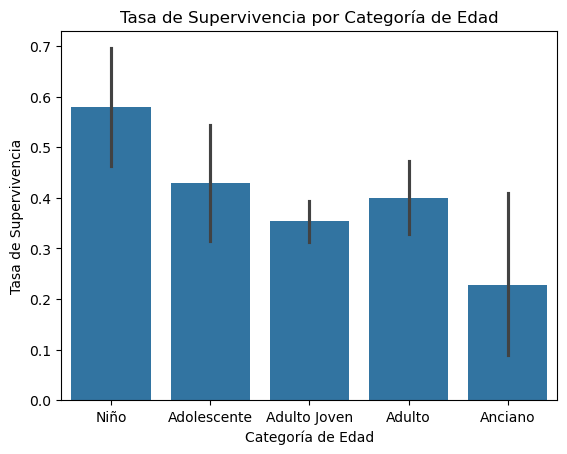

In [21]:
sns.barplot(x='edad_categoria', y='survived', data=nuevo_df) # Crea un gráfico de barras utilizando la función barplot de seaborn para mostrar la relación entre la categoría de edad ('edad_categoria') y la supervivencia ('survived') en el DataFrame nuevo_df. El eje x representa las categorías de edad, mientras que el eje y representa la tasa de supervivencia para cada categoría.
plt.title('Tasa de Supervivencia por Categoría de Edad') # Agrega un título al gráfico de barras para describir la información que se está mostrando, en este caso, la tasa de supervivencia por categoría de edad.
plt.xlabel('Categoría de Edad') # Etiqueta el eje x del gráfico de barras con 'Categoría de Edad' para indicar que las categorías de edad se representan en ese eje.
plt.ylabel('Tasa de Supervivencia') # Etiqueta el eje y del gráfico de barras con 'Tasa de Supervivencia' para indicar que la tasa de supervivencia se representa en ese eje.
plt.show() # Muestra el gráfico de barras generado para visualizar la relación entre la categoría de edad y la tasa de supervivencia en el DataFrame nuevo_df.

C:\Users\Fran\AppData\Local\Temp\ipykernel_21728\1809906795.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='acompanantes', y='survived', data=nuevo_df, ci=None) # Crea un gráfico de barras utilizando la función barplot de seaborn para mostrar la relación entre la categoría de edad ('edad_categoria') y la supervivencia ('survived') en el DataFrame nuevo_df. El eje x representa las categorías de edad, mientras que el eje y representa la tasa de supervivencia para cada categoría.


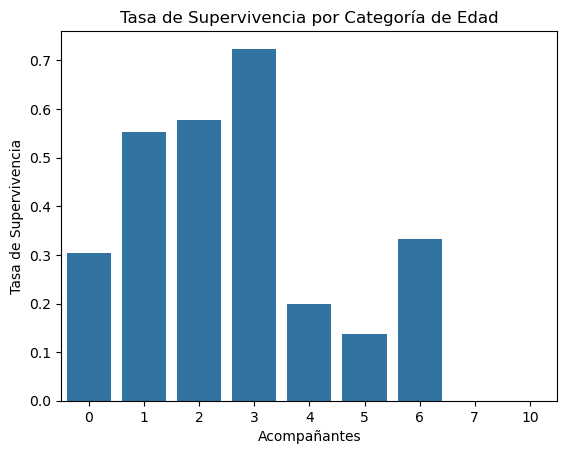

In [28]:
sns.barplot(x='acompanantes', y='survived', data=nuevo_df, ci=None) # Crea un gráfico de barras utilizando la función barplot de seaborn para mostrar la relación entre la categoría de edad ('edad_categoria') y la supervivencia ('survived') en el DataFrame nuevo_df. El eje x representa las categorías de edad, mientras que el eje y representa la tasa de supervivencia para cada categoría.
plt.title('Tasa de Supervivencia por Categoría de Edad') # Agrega un título al gráfico de barras para describir la información que se está mostrando, en este caso, la tasa de supervivencia por categoría de edad.
plt.xlabel('Acompañantes') # Etiqueta el eje x del gráfico de barras con 'Acompañantes' para indicar que las categorías de acompañantes se representan en ese eje.
plt.ylabel('Tasa de Supervivencia') # Etiqueta el eje y del gráfico de barras con 'Tasa de Supervivencia' para indicar que la tasa de supervivencia se representa en ese eje.
plt.show() # Muestra el gráfico de barras generado para visualizar la relación entre la categoría de edad y la tasa de supervivencia en el DataFrame nuevo_df.

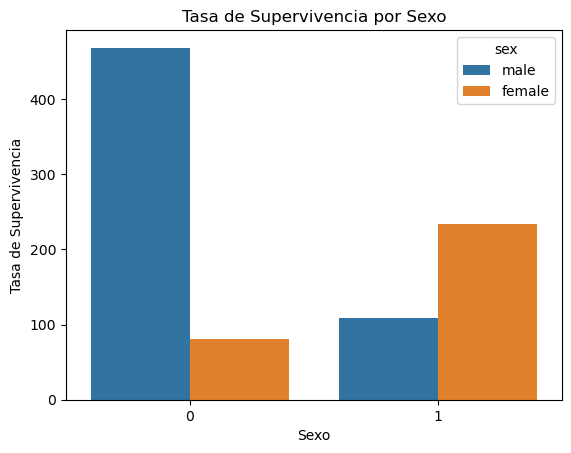

In [29]:
sns.countplot(x='survived', data=nuevo_df, hue='sex') # Crea un gráfico de barras utilizando la función barplot de seaborn para mostrar la relación entre el sexo ('sex') y la supervivencia ('survived') en el DataFrame nuevo_df. El eje x representa las categorías de sexo, mientras que el eje y representa la tasa de supervivencia para cada categoría.
plt.title('Tasa de Supervivencia por Sexo') # Agrega un título al gráfico de barras para describir la información que se está mostrando, en este caso, la tasa de supervivencia por sexo.
plt.xlabel('Sexo') # Etiqueta el eje x del gráfico de barras con 'Sexo' para indicar que las categorías de sexo se representan en ese eje.
plt.ylabel('Tasa de Supervivencia') # Etiqueta el eje y del gráfico de barras con 'Tasa de Supervivencia' para indicar que la tasa de supervivencia se representa en ese eje.
plt.show() # Muestra el gráfico de barras generado para visualizar la relación entre la categoría de edad y la tasa de supervivencia en el DataFrame nuevo_df.

Ingeniería de características (atributos) para dejar el DataFrame preparado para algoritmos de IA

In [30]:
nuevo_df

,survived,pclass,sex,age,embarked,acompanantes,edad_categoria
0,0,3,male,22.000000,S,1,Adulto Joven
1,1,1,female,38.000000,C,1,Adulto
2,1,3,female,26.000000,S,0,Adulto Joven
3,1,1,female,35.000000,S,1,Adulto Joven
4,0,3,male,35.000000,S,0,Adulto Joven
...,...,...,...,...,...,...,...
886,0,2,male,27.000000,S,0,Adulto Joven
887,1,1,female,19.000000,S,0,Adulto Joven
888,0,3,female,29.699118,S,3,Adulto Joven
889,1,1,male,26.000000,C,0,Adulto Joven


Elimino el campo age porque es un valor discreto y ya tengo la categoría 'edad_categoría'

In [32]:
nuevo_df.drop(['age'], axis=1, inplace=True) # Elimina las columnas 'age' y 'edad_categoria' del DataFrame nuevo_df. El parámetro axis=1 indica que se deben eliminar columnas, y inplace=True indica que se debe modificar el DataFrame original en lugar de crear una copia.
nuevo_df

C:\Users\Fran\AppData\Local\Temp\ipykernel_21728\748076564.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nuevo_df.drop(['age'], axis=1, inplace=True) # Elimina las columnas 'age' y 'edad_categoria' del DataFrame nuevo_df. El parámetro axis=1 indica que se deben eliminar columnas, y inplace=True indica que se debe modificar el DataFrame original en lugar de crear una copia.


,survived,pclass,sex,embarked,acompanantes,edad_categoria
0,0,3,male,S,1,Adulto Joven
1,1,1,female,C,1,Adulto
2,1,3,female,S,0,Adulto Joven
3,1,1,female,S,1,Adulto Joven
4,0,3,male,S,0,Adulto Joven
...,...,...,...,...,...,...
886,0,2,male,S,0,Adulto Joven
887,1,1,female,S,0,Adulto Joven
888,0,3,female,S,3,Adulto Joven
889,1,1,male,C,0,Adulto Joven


Elimino 'embarked' porque no creo que influya en un estudio de supervivencia

In [33]:
nuevo_df.drop(['embarked'], axis=1, inplace=True) # Elimina las columnas 'age' y 'edad_categoria' del DataFrame nuevo_df. El parámetro axis=1 indica que se deben eliminar columnas, y inplace=True indica que se debe modificar el DataFrame original en lugar de crear una copia.
nuevo_df

C:\Users\Fran\AppData\Local\Temp\ipykernel_21728\563659169.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nuevo_df.drop(['embarked'], axis=1, inplace=True) # Elimina las columnas 'age' y 'edad_categoria' del DataFrame nuevo_df. El parámetro axis=1 indica que se deben eliminar columnas, y inplace=True indica que se debe modificar el DataFrame original en lugar de crear una copia.


,survived,pclass,sex,acompanantes,edad_categoria
0,0,3,male,1,Adulto Joven
1,1,1,female,1,Adulto
2,1,3,female,0,Adulto Joven
3,1,1,female,1,Adulto Joven
4,0,3,male,0,Adulto Joven
...,...,...,...,...,...
886,0,2,male,0,Adulto Joven
887,1,1,female,0,Adulto Joven
888,0,3,female,3,Adulto Joven
889,1,1,male,0,Adulto Joven


In [34]:
# Si el sexo es masculino, asignar 1, si es femenino, asignar 0
nuevo_df['hombre'] = nuevo_df['sex'].apply(lambda x: True if x == 'male' else False) # Crea una nueva columna llamada 'hombre' en el DataFrame nuevo_df que asigna el valor True si el sexo es masculino ('male') y False si el sexo es femenino ('female'). La función apply se utiliza para aplicar una función lambda a cada valor de la columna 'sex'.
nuevo_df.drop(columns=['sex'], inplace=True) # Elimina la columna 'sex' del DataFrame nuevo_df, ya que la información de esta columna ahora está representada en la nueva columna 'hombre'. El parámetro inplace=True indica que se debe modificar el DataFrame original en lugar de crear una copia.
nuevo_df


C:\Users\Fran\AppData\Local\Temp\ipykernel_21728\3148050976.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nuevo_df['hombre'] = nuevo_df['sex'].apply(lambda x: True if x == 'male' else False) # Crea una nueva columna llamada 'hombre' en el DataFrame nuevo_df que asigna el valor True si el sexo es masculino ('male') y False si el sexo es femenino ('female'). La función apply se utiliza para aplicar una función lambda a cada valor de la columna 'sex'.
C:\Users\Fran\AppData\Local\Temp\ipykernel_21728\3148050976.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,survived,pclass,acompanantes,edad_categoria,hombre
0,0,3,1,Adulto Joven,True
1,1,1,1,Adulto,False
2,1,3,0,Adulto Joven,False
3,1,1,1,Adulto Joven,False
4,0,3,0,Adulto Joven,True
...,...,...,...,...,...
886,0,2,0,Adulto Joven,True
887,1,1,0,Adulto Joven,False
888,0,3,3,Adulto Joven,False
889,1,1,0,Adulto Joven,True


In [35]:
nuevo_df = pd.get_dummies(nuevo_df['edad_categoria'], prefix='edad', drop_first=True).join(nuevo_df.drop(['edad_categoria'], axis=1)) # Crea un nuevo DataFrame llamado df_nuevo a partir del DataFrame nuevo_df utilizando la función get_dummies de pandas para convertir la columna 'edad_categoria' en variables dummy (variables indicadoras). El parámetro columns especifica la columna que se va a convertir, y drop_first=True indica que se debe eliminar la primera categoría para evitar la multicolinealidad. Luego, se une este nuevo DataFrame con el DataFrame original nuevo_df sin la columna 'edad_categoria' utilizando la función join.
nuevo_df

,edad_Adolescente,edad_Adulto Joven,edad_Adulto,edad_Anciano,survived,pclass,acompanantes,hombre
0,False,True,False,False,0,3,1,True
1,False,False,True,False,1,1,1,False
2,False,True,False,False,1,3,0,False
3,False,True,False,False,1,1,1,False
4,False,True,False,False,0,3,0,True
...,...,...,...,...,...,...,...,...
886,False,True,False,False,0,2,0,True
887,False,True,False,False,1,1,0,False
888,False,True,False,False,0,3,3,False
889,False,True,False,False,1,1,0,True


In [36]:
# One-hot encoding para la columna 'pclass' y 'acompanantes'
nuevo_df = pd.get_dummies(nuevo_df.pclass, prefix='pclass', drop_first=True).join(pd.get_dummies(nuevo_df.acompanantes, prefix='acompanantes', drop_first=True)).join(nuevo_df.drop(['pclass', 'acompanantes'], axis=1)) # Aplica one-hot encoding a las columnas 'pclass' y 'acompanantes'
nuevo_df

,pclass_2,pclass_3,acompanantes_1,acompanantes_2,acompanantes_3,acompanantes_4,acompanantes_5,acompanantes_6,acompanantes_7,acompanantes_10,edad_Adolescente,edad_Adulto Joven,edad_Adulto,edad_Anciano,survived,hombre
0,False,True,True,False,False,False,False,False,False,False,False,True,False,False,0,True
1,False,False,True,False,False,False,False,False,False,False,False,False,True,False,1,False
2,False,True,False,False,False,False,False,False,False,False,False,True,False,False,1,False
3,False,False,True,False,False,False,False,False,False,False,False,True,False,False,1,False
4,False,True,False,False,False,False,False,False,False,False,False,True,False,False,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,True,False,False,False,False,False,False,False,False,False,False,True,False,False,0,True
887,False,False,False,False,False,False,False,False,False,False,False,True,False,False,1,False
888,False,True,False,False,True,False,False,False,False,False,False,True,False,False,0,False
889,False,False,False,False,False,False,False,False,False,False,False,True,False,False,1,True


In [39]:
nuevo_df = nuevo_df[['hombre']].join(nuevo_df.drop(['hombre'], axis=1)) # Elimina las columnas 'age' y 'edad_categoria' del DataFrame nuevo_df. El parámetro axis=1 indica que se deben eliminar columnas, y inplace=True indica que se debe modificar el DataFrame original en lugar de crear una copia.
nuevo_df.to_csv('../data/titanic_ia.csv', index=False) # Guarda el DataFrame nuevo_df en un archivo CSV llamado 'titanic_limpio.csv' sin incluir los índices de las filas. El parámetro index=False indica que no se deben escribir los índices en el archivo CSV.